<a href="https://colab.research.google.com/github/Hiro-92/Team.-/blob/hero/%EB%84%A4%EC%9D%B4%EB%B2%84_%EC%97%B0%EC%98%88_%EB%9E%AD%ED%82%B9_%EB%89%B4%EC%8A%A4_%EA%B3%B5%EA%B0%90_%EC%A2%85%EB%A5%98%EB%B3%84_%EA%B8%B0%EC%82%AC_%ED%81%AC%EB%A1%A4%EB%A7%81%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

한글패치

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

!apt -qq -y install fonts-nanum

import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')
mpl.font_manager._rebuild()

fonts-nanum is already the newest version (20170925-1).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


셀레니움 웹드라이버에서 가져오기

In [ ]:
#이 부분은 처음 한번만 실행하면 됌.
!pip install selenium
!apt-get update
!apt install chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 985 kB 3.9 MB/s 
     |████████████████████████████████| 358 kB 44.3 MB/s 
     |████████████████████████████████| 140 kB 43.7 MB/s 
     |████████████████████████████████| 58 kB 4.0 MB/s 
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.24.3
    Uninstalling urllib3-1.24.3:
      Successfully uninstalled urllib3-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
requests 2.23.0 requires urllib3!=1.25.0,!=1.25.1,<1.26,>=1.21.1, but you have urllib3 1.26.12 which is incompatible.
Get:1 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran40/ InRelease [3,626 B]
Get:3 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu

원하는 종류의 감정 뉴스를 선택하세요
love, cheer, congrats, expect, surprise, sad 중에 입력해주세요sad


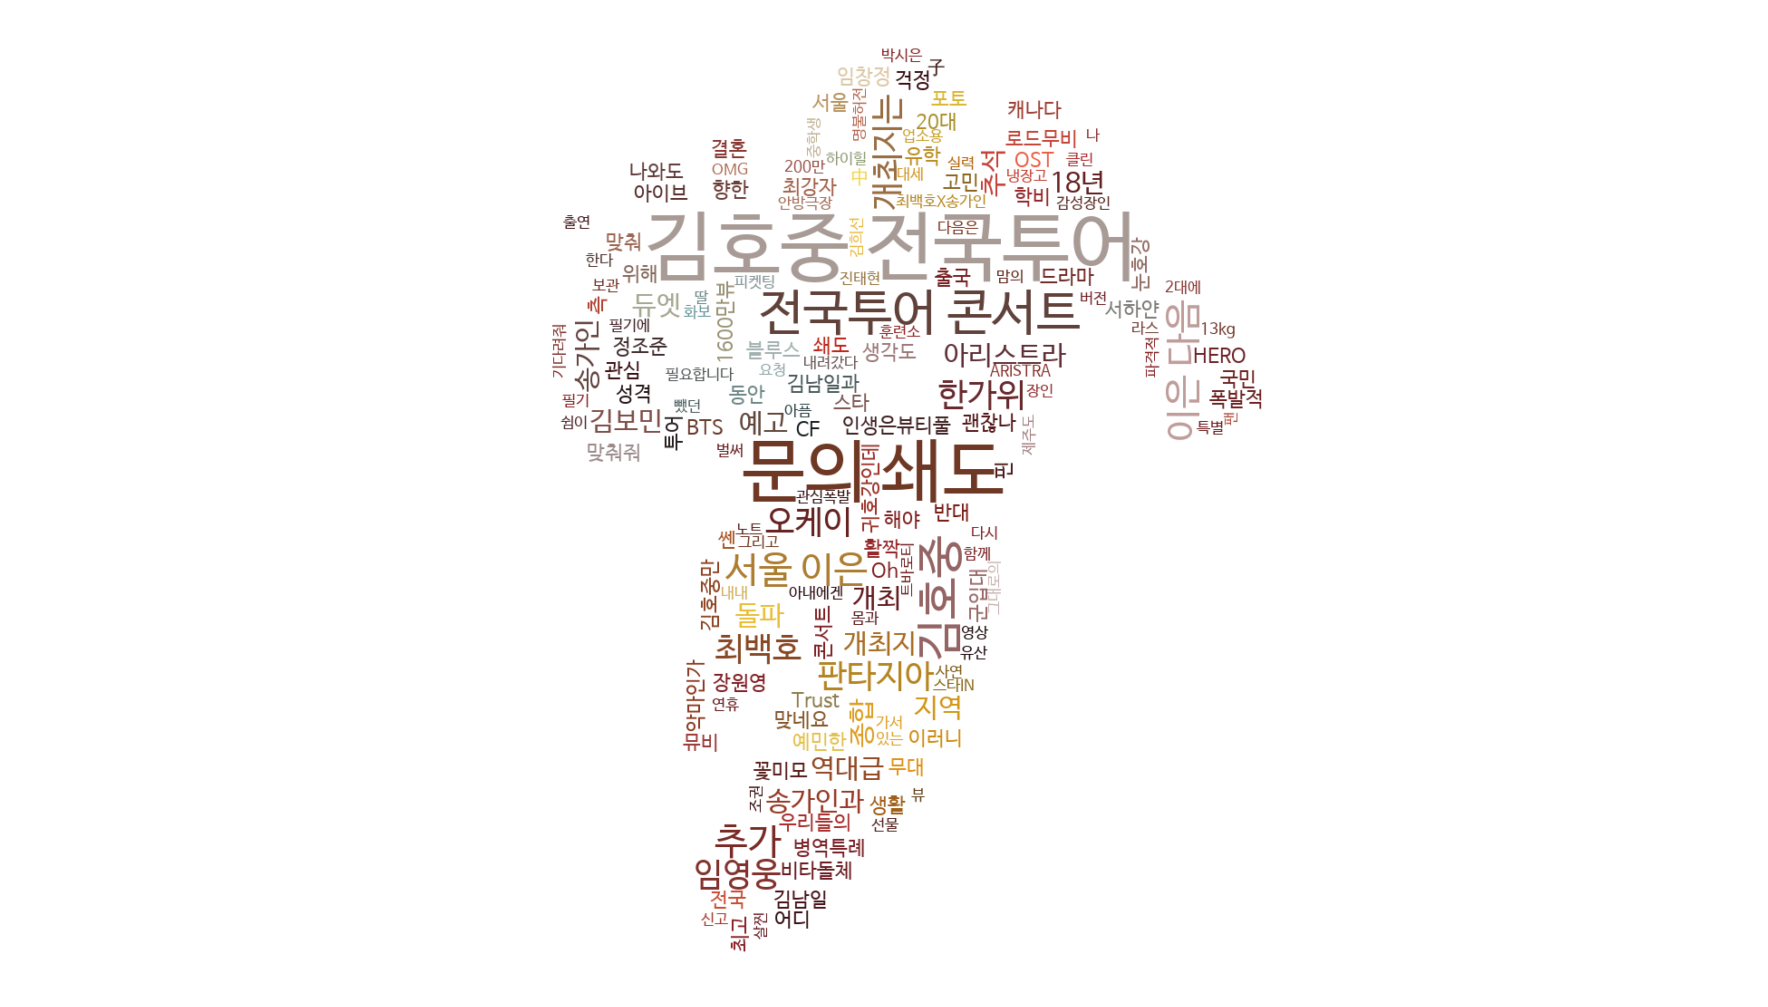

In [ ]:
# 라이브러리 임포트
from urllib.request import urlopen
from selenium import webdriver
from bs4 import BeautifulSoup

import time
from pytz import timezone
import datetime

import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# 1) 데이터 프레임 생성
data = pd.DataFrame(columns=['순위','공감종류','기사제목','기사링크','공감수','수집일자'])

# 2) 네이버 랭킹 뉴스 접속 주소 준비 : https://entertain.naver.com/ranking/sympathy
want_sym = input('원하는 종류의 감정 뉴스를 선택하세요'+ '\n'+ 'love, cheer, congrats, expect, surprise, sad 중에 입력해주세요')

url = 'https://entertain.naver.com/ranking/sympathy/{}'.format(want_sym)

# 3) url에서 html 가져오기
html = urlopen(url)

# 4) html을 파싱할 수 있는 object로 변환
bsObject = BeautifulSoup(html, 'html.parser', from_encoding='utf-8')

# 5) 필요한 기사정보를 담고 있는 li 태그들 불러오기
li = bsObject.find_all('li',{'class','_inc_news_lst3_rank_reply'})
# 5) 감정정보 가져오기
li_2 = bsObject.find('li',{'class','likeitnews_nav_item is_{} is_selected'.format(want_sym)})
kind_sym = li_2.find('div',{'class','likeitnews_nav_item_name'}).text #공감종류

for index_l in range(0,len(li)):
    try:
        # 순위
        rank = li[index_l].find('em', {'class', 'blind'}).text.replace('\n','').replace('\t','').strip()

        # 공감종류
        emotion = kind_sym

        # 뉴스제목

        title = li[index_l].find('a', {'class', 'tit'}).text.replace('\n','').replace('\t','').strip()

        #뉴스 내용
        summary = li[index_l].find('p',{'class','summary'}).text.replace('\n', '').replace('\t', '' ).strip()

        # 공감수
        like = li[index_l].find('a',{'class','likeitnews_item_likeit {}'.format(want_sym)}).text.replace('\n', '').replace('\t', '' ).strip()

        # 뉴스 링크
        link = 'https://entertain.naver.com/' + li[index_l].find('a').attrs['href']

        # dataframe 저장(append)
        data = data.append({'순위' : rank,
                            '공감종류' : emotion,
                            '기사제목' : title,
                            '기사링크' : link,
                            '기사내용' : summary,
                            '공감수' : like,
                            '수집일자' : datetime.datetime.now(timezone('Asia/Seoul')).strftime('%Y-%m-%d %H:%M:%S')}, ignore_index = True)

    except:
        pass

import matplotlib.pyplot as plt
import matplotlib
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

import re

def clean_text(inputString):
  text_rmv = re.sub('[-=+,#/\?:^.@*\"※~ㆍ!』‘|\(\)\[\]`\'…》\”\“\’·]', ' ', inputString)
  return text_rmv

day_text = " ".join(clean_text(li) for li in data.기사제목.astype(str))
day_text

import numpy as np
from PIL import Image # Python Image Library

matplotlib.rcParams['figure.figsize'] = (16.0, 9.0)

mask = np.array(Image.open('/content/iron_man.jpg'))
stopwords = set(STOPWORDS)
image_colors = ImageColorGenerator(mask)

wordcloud = WordCloud(background_color = 'white', width=1280, height=628, stopwords=stopwords, mask= mask, font_path=fontpath).generate(day_text)
plt.figure()
plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation='bilinear')
plt.axis('off')
plt.show()